# CRIST

End-to-end run of CRIST on the human skin setting of the paper: pretraining on two healthy Xenium sections, adaptation to an independent melanoma section, and comparison with Cell2location against the section's cell-level ground truth. Run the cells from top to bottom; each step sets its hyperparameters (the values of the Supplementary Note) in the cell before it runs. All paths are relative to this folder:

| folder | content |
|---|---|
| `data/<sample>/` | raw inputs of each Xenium section: `cell_feature_matrix.h5`, `cells.parquet`, `transcripts.parquet`, `cell_boundaries.csv`, `<sample>.tif` (registered H&E) |
| `data/human_skin_normal_plus_melanoma/sc.h5ad` | the 13-class single-cell skin atlas (labels in step 0, Cell2location reference in step 4) |
| `cellvit/`, `bin2cell/` | CellViT source code (checkpoint: `cellvit/models/pretrained/CellViT/CellViT-SAM-H-x40.pth`) and the bin2cell package |
| `cellvit_output/<sample>/cell_detection/cells.pt` | CellViT nuclei of each section (step 2 reuses them if present) |
| `output/` | everything the notebook computes; each step reuses its output folder if it exists (delete it to recompute) |

Environment (conda files in `envs/`, see `README.md`): the kernel env `crist` (python 3.13, torch 2.6 with CUDA, scanpy, cell2location 0.1.4, scvi-tools 1.3.0) runs steps 1 and 3–7 on one GPU; TACCO 0.4.0 runs in `tacco_env`, bin2cell in `visium_hd_annotation` and CellViT in `cellvit_env` (python 3.9.7, torch 2.0), which are called as subprocesses and expected next to the kernel env (`ENV_PYTHON` in `annotation.py`, `CELLVIT_PYTHON` in `nuclei_segmentation.py`).

## Step 0 — Cell-type labels for the high-resolution samples (TACCO)

`annotation.py` labels every cell of a high-resolution sample against the single-cell atlas with TACCO. Three input layouts:

1. **Xenium** — one profile per vendor-segmented cell (`cell_feature_matrix.h5`, positions from `cells.parquet`);
2. **Visium HD with Space Ranger segmentation** — one profile per segmented cell (`segmented_outputs/`);
3. **Visium HD without segmentation** — the CellViT nuclei of the H&E image (step 2, `cells.json`) are rasterised into a label image, expanded by up to `max_bin_distance` 2 µm bins to cell footprints (bin2cell's rule), and the bins of each footprint are summed to a cell profile.

TACCO builds one reference profile per atlas class and assigns each cell one class (`max_annotation = 1`) → `obs['cell_type_tacco']` (NaN for cells without any count in a gene shared with the atlas; they are left out of the compositions in step 1). TACCO and bin2cell run as subprocesses in their own conda envs.

| name | value | meaning |
|---|---|---|
| `labels_key` | `cell_type` | atlas `obs` column holding the classes |
| `max_annotation` | 1 | classes TACCO may assign to a cell (1 = hard label) |
| `seed` | 0 | numpy seed set before TACCO |
| `bin_size`, `max_bin_distance` (Visium HD without segmentation) | 2um, 2 | Visium HD bin size and bin2cell expansion radius in bins |

In [ ]:
from pathlib import Path
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("data")                                                  # one sub-directory per Xenium sample
PRETRAIN_SAMPLES = ["Xenium_human_skin_s1", "Xenium_human_skin_s2"]         # healthy human skin, two sections
TARGET_SAMPLE = "Xenium_skin_disease"                                       # cutaneous melanoma, the evaluation target
ATLAS = DATA_ROOT / "human_skin_normal_plus_melanoma" / "sc.h5ad"          # scRNA-seq atlas the cells were labelled with
OUTPUT = Path("output")

# The atlas classes define one label space shared by every sample.
cell_types = sorted(ad.read_h5ad(ATLAS, backed="r").obs["cell_type"].cat.categories)
print(f"{len(cell_types)} cell types: {cell_types}")
palette = dict(zip(cell_types, plt.cm.tab20.colors[::2] + plt.cm.tab20.colors[1::2]))   # one colour per class, used in every figure

13 cell types: ['FB', 'KC', 'LE', 'MELA', 'Mast', 'Melanoma', 'Mye', 'Peri', 'SGEC', 'SMC', 'Schwann', 'T/NK', 'VE']


In [2]:
import annotation as an

TACCO_HP = dict(labels_key="cell_type", max_annotation=1, seed=0)

annotations = {name: an.annotate_xenium(DATA_ROOT / name, ATLAS, OUTPUT / "annotation" / f"{name}.h5ad", **TACCO_HP)
               for name in PRETRAIN_SAMPLES + [TARGET_SAMPLE]}

$ /home/sky/miniconda3/envs/tacco_env/bin/python /home/sky/research/nature_machine_intelligence/final_version_align_check/CRIST/annotation.py xenium --sample_dir data/Xenium_human_skin_s1 --atlas data/human_skin_normal_plus_melanoma/sc.h5ad --out output/annotation/Xenium_human_skin_s1.h5ad --labels_key cell_type --max_annotation 1 --seed 0


Xenium_human_skin_s1: 68,476 cells x 377 genes


cells (68476, 377), atlas (54063, 21701), shared genes 341


Starting preprocessing


Finished preprocessing in 3.25 seconds.


...

LE            304


Schwann        98


MELA           27


SGEC           12


saved output/annotation/Xenium_skin_disease.h5ad


### Manual correction (Optional)

The two healthy sections should not contain melanoma cells; the cells TACCO labelled `Melanoma` there are corrected to `MELA` (melanocytes). The TACCO call is kept in `obs['cell_type_tacco_raw']`. The melanoma target is not corrected. This correction is only used when the sc and st are not fully matched, e.g., use the sc with maglicant cells to annotate the health samples.

In [3]:
CORRECTION = {"Melanoma": "MELA"}
for name in PRETRAIN_SAMPLES:
    an.manual_correction(annotations[name], CORRECTION)

/home/sky/research/nature_machine_intelligence/final_version_align_check/CRIST/annotation.py:272: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cells.obs[RESULT_KEY] = raw.replace(mapping)
/home/sky/research/nature_machine_intelligence/final_version_align_check/CRIST/annotation.py:272: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cells.obs[RESULT_KEY] = raw.replace(mapping)


Xenium_human_skin_s1: 2,855 Melanoma cells corrected to MELA
Xenium_human_skin_s2: 3,659 Melanoma cells corrected to MELA


In [4]:
counts = {name: ad.read_h5ad(path, backed="r").obs["cell_type_tacco"].value_counts(dropna=False) for name, path in annotations.items()}
pd.DataFrame(counts).fillna(0).astype(int).rename(index={np.nan: "unlabelled (NaN)"})

,Xenium_human_skin_s1,Xenium_human_skin_s2,Xenium_skin_disease
cell_type_tacco,,,
FB,14888,16640,18880
KC,16458,30280,3961
LE,1109,1263,304
MELA,3006,3881,27
Mast,847,735,367
Melanoma,0,0,29726
Mye,3677,3393,10367
Peri,2268,2886,1434
SGEC,95,57,12


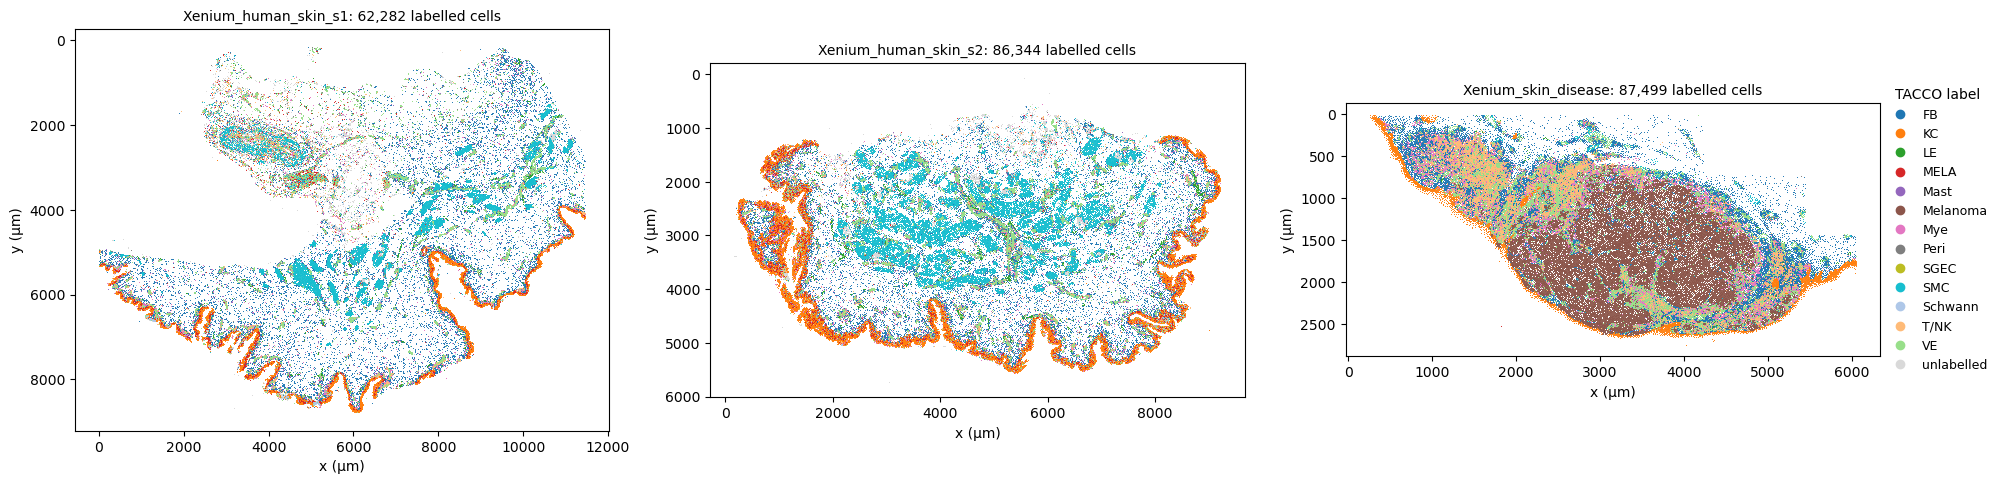

In [5]:
# The labelled cells of the three sections in the Xenium coordinate frame (grey: cells TACCO could not label).
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, name in zip(axes, PRETRAIN_SAMPLES + [TARGET_SAMPLE]):
    cells = ad.read_h5ad(annotations[name])
    lab, xy = cells.obs["cell_type_tacco"], np.asarray(cells.obsm["spatial"])
    ax.scatter(xy[lab.isna(), 0], xy[lab.isna(), 1], s=0.5, c="#d9d9d9", linewidths=0, rasterized=True)
    for ct in cell_types:
        m = (lab == ct).to_numpy()
        if m.any():
            ax.scatter(xy[m, 0], xy[m, 1], s=0.5, c=[palette[ct]], linewidths=0, rasterized=True)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
    ax.set_title(f"{name}: {lab.notna().sum():,} labelled cells", fontsize=10)
handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=6, color=palette[ct], label=ct) for ct in cell_types]
handles.append(plt.Line2D([], [], marker="o", linestyle="", markersize=6, color="#d9d9d9", label="unlabelled"))
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.99, 0.5), frameon=False, fontsize=9, title="TACCO label")
plt.tight_layout(); plt.show()

The other two layouts are called the same way: `annotate_hd_bin2cell` (bin2cell in `BIN2CELL_ENV`, then TACCO in `TACCO_ENV`; needs `cellvit_output/<HD sample>/cell_detection/cells.json` from step 2) and `annotate_hd_segmented` (TACCO in `TACCO_ENV`):

```python
an.annotate_hd_bin2cell(visium_hd_path="data/<HD sample>", he_image="data/<HD sample>/<HD sample>.tif",
                        cellvit_dir="cellvit_output/<HD sample>/cell_detection", atlas_h5ad=ATLAS,
                        out_dir=OUTPUT / "annotation" / "<HD sample>", labels_key="cell_type", bin_size="2um", max_bin_distance=2)
an.annotate_hd_segmented(segmented_dir="data/<HD sample>/segmented_outputs", atlas_h5ad=ATLAS,
                         out=OUTPUT / "annotation" / "<HD sample>.h5ad", labels_key="cell_type")
```

## Step 1 — Pseudo-spots from the annotated high-resolution samples

`pseudo_spots.build_pseudo_spots` aggregates each section into Visium-sized pseudo-spots: a hexagonal lattice with 55 µm pitch (inradius 27.5 µm) over the annotated cells; every transcript of `transcripts.parquet` goes to the nearest centre → `X` (raw counts of all Xenium features, control codewords included); every labelled cell (centroid of its `cell_boundaries.csv` polygon) goes to the nearest centre → `obs['n_<type>']`, the composition label; a spot is kept if it has ≥ 10 transcripts or ≥ 1 labelled cell. The atlas classes define one label space for all samples; the target's labels are used only for evaluation.

In [6]:
import pseudo_spots as ps

pseudo = {name: ps.build_pseudo_spots(DATA_ROOT / name, annotations[name], cell_types) for name in PRETRAIN_SAMPLES + [TARGET_SAMPLE]}
pd.DataFrame([ps.summarize(a) for a in pseudo.values()], index=list(pseudo))

,spots,features,control-codeword features,segmented cells,labelled cells,labelled cells / spot (mean),spots without labelled cells,transcripts / spot (median),features / spot (median)
Xenium_human_skin_s1,17555,541,164,68476,62282,3.55,4157,42.0,23.0
Xenium_human_skin_s2,11574,541,164,90106,86344,7.46,775,69.0,29.0
Xenium_skin_disease,4723,541,159,87499,87499,18.53,1035,3883.0,233.0


In [7]:
# What one pseudo-spot dataset looks like: raw transcript counts in X, exact cell-type counts in obs.
adata = pseudo[PRETRAIN_SAMPLES[0]]
print(adata)
label_cols = [f"n_{ct}" for ct in cell_types]
adata.obs.loc[adata.obs["total_cells"] > 0, label_cols + ["total_cells", "total_counts"]].head()

AnnData object with n_obs × n_vars = 17555 × 541
    obs: 'n_FB', 'n_KC', 'n_LE', 'n_MELA', 'n_Mast', 'n_Melanoma', 'n_Mye', 'n_Peri', 'n_SGEC', 'n_SMC', 'n_Schwann', 'n_T/NK', 'n_VE', 'total_counts', 'n_genes', 'total_cells', 'in_tissue'
    uns: 'pseudo_spots'
    obsm: 'spatial'


,n_FB,n_KC,n_LE,n_MELA,n_Mast,n_Melanoma,n_Mye,n_Peri,n_SGEC,n_SMC,n_Schwann,n_T/NK,n_VE,total_cells,total_counts
spot_19,1,0,0,0,0,0,0,0,0,0,0,0,0,1,26
spot_20,0,0,0,0,0,0,0,1,0,0,0,0,1,2,80
spot_21,0,0,0,0,0,0,0,1,0,0,0,0,0,1,39
spot_22,0,0,0,0,0,0,0,1,0,0,0,0,3,4,153
spot_23,0,0,0,0,0,0,0,0,0,0,0,0,2,2,19


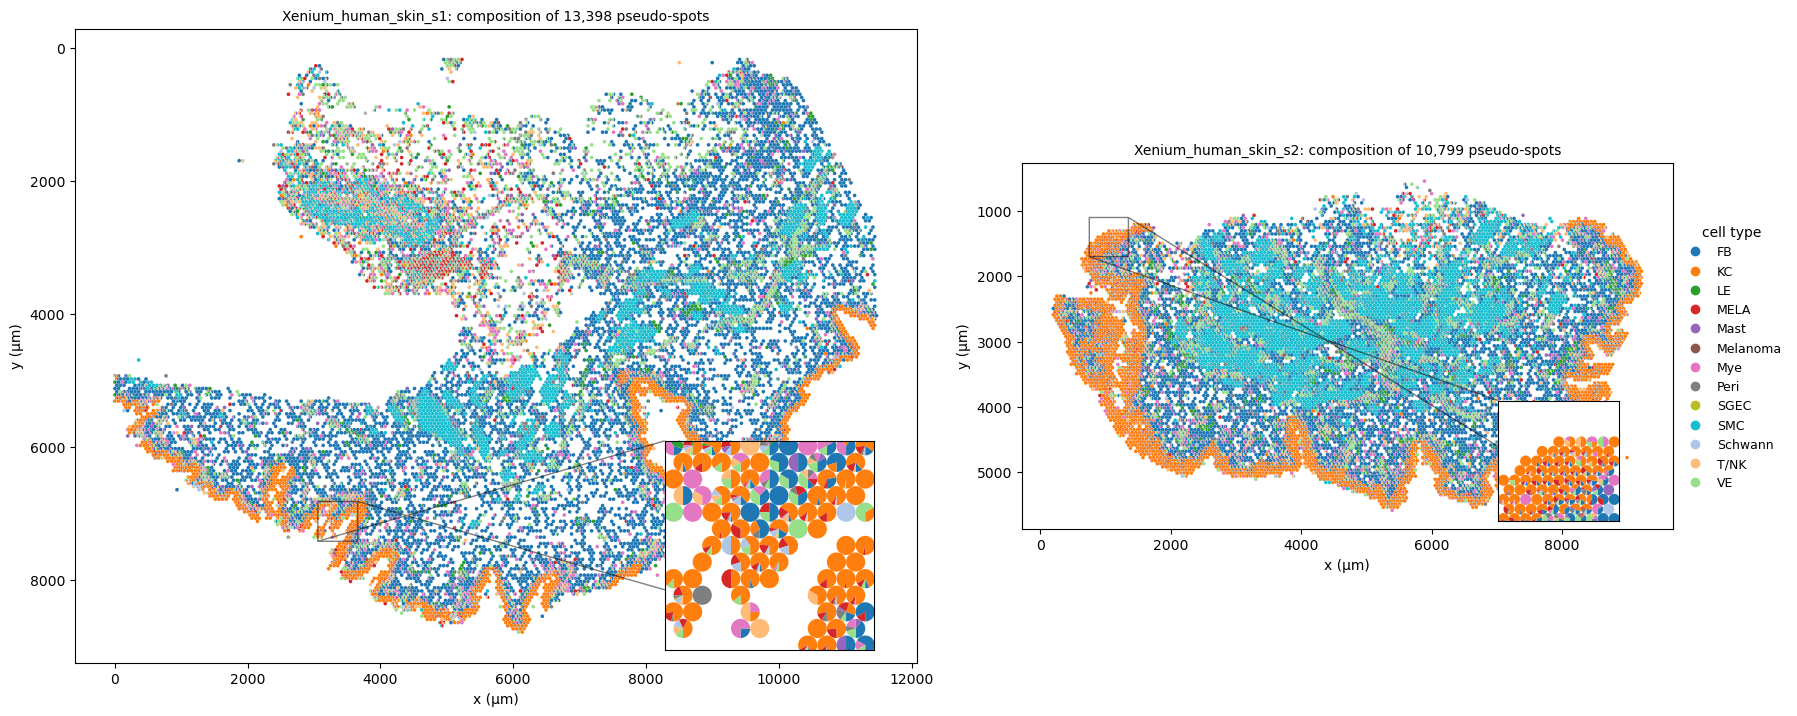

In [8]:
import plotting

# Pie map of the two pretraining sections: every pseudo-spot is a pie of its cell composition (spots without labelled cells are omitted);
# the inset shows a 0.6 x 0.6 mm window around the densest spot at spot scale.
fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [12.5, 9.5]})
colors = [palette[ct] for ct in cell_types]
for ax, name in zip(axes, PRETRAIN_SAMPLES):
    a = pseudo[name]
    xy, counts = a.obsm["spatial"], a.obs[label_cols].to_numpy(dtype=float)
    plotting.pie_map(ax, xy, counts / np.maximum(counts.sum(axis=1, keepdims=True), 1), colors, radius=ps.SPOT_DIAMETER_UM / 2)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
    ax.set_title(f"{name}: composition of {int((counts.sum(axis=1) > 0).sum()):,} pseudo-spots", fontsize=10)
    cx, cy = xy[counts.sum(axis=1).argmax()]
    axins = ax.inset_axes([0.66, 0.02, 0.33, 0.33])
    win = (np.abs(xy[:, 0] - cx) < 300) & (np.abs(xy[:, 1] - cy) < 300)
    plotting.pie_map(axins, xy[win], (counts / np.maximum(counts.sum(axis=1, keepdims=True), 1))[win], colors, radius=ps.SPOT_DIAMETER_UM / 2)
    axins.set_xlim(cx - 300, cx + 300); axins.set_ylim(cy + 300, cy - 300); axins.set_aspect("equal"); axins.set_xticks([]); axins.set_yticks([])
    ax.indicate_inset_zoom(axins, edgecolor="black")
handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=6, color=palette[ct], label=ct) for ct in cell_types]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.99, 0.5), frameon=False, fontsize=9, title="cell type")
plt.tight_layout(); plt.show()

## Step 2 — Nuclei of the H&E image (CellViT)

`nuclei_segmentation.segment_nuclei` runs CellViT as subprocesses in `cellvit_env`: patch extraction from the registered H&E image (0.2125 µm/px; 1,024 px patches at 40×, 64 px overlap, Macenko stain normalisation, every tile kept) and CellViT-SAM-H inference with de-duplication in the overlap zones. `cells.pt` holds, per nucleus, the 1,280-d embedding (`x`), the centroid in H&E pixels (`positions`) and the outline (`contours`). An existing `cells.pt` is reused (about 13–30 min per section on one RTX 4090 otherwise).

In [9]:
import nuclei_segmentation as ns

HE_MPP = 0.2125                              # µm per H&E pixel (Xenium post-run H&E, registered to the Xenium frame)
CELLVIT_OUTPUT = Path("cellvit_output")      # <sample>/patches and <sample>/cell_detection/cells.pt

cells_pt = {name: ns.segment_nuclei(DATA_ROOT / name / f"{name}.tif", CELLVIT_OUTPUT, HE_MPP, ns.CELLVIT_CHECKPOINT)
            for name in PRETRAIN_SAMPLES + [TARGET_SAMPLE]}

Xenium_human_skin_s1.tif: using existing cellvit_output/Xenium_human_skin_s1/cell_detection/cells.pt
Xenium_human_skin_s2.tif: using existing cellvit_output/Xenium_human_skin_s2/cell_detection/cells.pt
Xenium_skin_disease.tif: using existing cellvit_output/Xenium_skin_disease/cell_detection/cells.pt


In [10]:
nuclei = {name: ns.load_cells(path) for name, path in cells_pt.items()}
pd.DataFrame({name: {"nuclei": c["embeddings"].shape[0],
                     "embedding dim": c["embeddings"].shape[1],
                     "x range (µm)": f"{c['positions'][:, 0].min() * HE_MPP:.0f} – {c['positions'][:, 0].max() * HE_MPP:.0f}",
                     "y range (µm)": f"{c['positions'][:, 1].min() * HE_MPP:.0f} – {c['positions'][:, 1].max() * HE_MPP:.0f}"}
              for name, c in nuclei.items()}).T

,nuclei,embedding dim,x range (µm),y range (µm)
Xenium_human_skin_s1,47608,1280,182 – 12244,199 – 8681
Xenium_human_skin_s2,67475,1280,143 – 9107,272 – 5097
Xenium_skin_disease,78007,1280,260 – 6048,1 – 2675


CellViT finds fewer nuclei than Xenium segmented from DAPI (step 1); CRIST's morphology branch uses only the H&E nuclei. The registered H&E of s2 ends at y = 5,228 µm, so 194 lattice spots beyond it receive no nuclei (zero-token rule).

<tifffile.TiffFile 'Xenium_human_skin_s1.tif'> shaped series shape does not match page shape


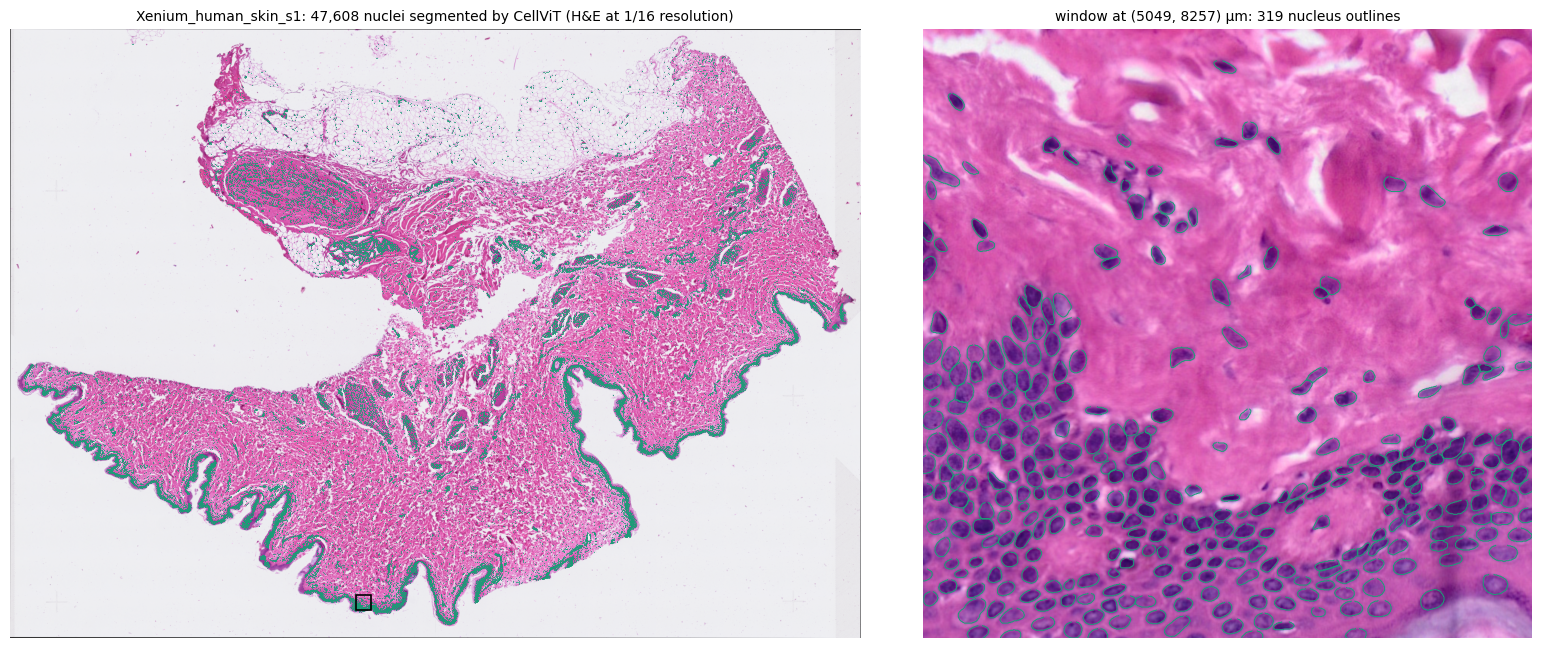

In [11]:
name = PRETRAIN_SAMPLES[0]
cells = nuclei[name]
pos = cells["positions"].numpy()

# Left: all CellViT nuclei of the section on a 1/16-resolution view of the H&E; right: the 1,024 px window with the most nuclei,
# with their outlines (the window is marked on the left).
overview, factor = ns.read_overview(DATA_ROOT / name / f"{name}.tif", level=4)
counts, xedges, yedges = np.histogram2d(pos[:, 0], pos[:, 1], bins=[int(overview.shape[1] * factor // 1024), int(overview.shape[0] * factor // 1024)])
ix, iy = np.unravel_index(counts.argmax(), counts.shape)
x0, y0 = int(xedges[ix]), int(yedges[iy])
inside = (pos[:, 0] >= x0) & (pos[:, 0] < x0 + 1024) & (pos[:, 1] >= y0) & (pos[:, 1] < y0 + 1024)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.5, 1]})
axes[0].imshow(overview)
axes[0].scatter(pos[:, 0] / factor, pos[:, 1] / factor, s=0.3, c="#1b9e77", linewidths=0, rasterized=True)
axes[0].add_patch(plt.Rectangle((x0 / factor, y0 / factor), 1024 / factor, 1024 / factor, fill=False, edgecolor="black", linewidth=1.2))
axes[0].set_title(f"{name}: {len(pos):,} nuclei segmented by CellViT (H&E at 1/16 resolution)", fontsize=10)
axes[0].set_axis_off()
axes[1].imshow(ns.read_region(DATA_ROOT / name / f"{name}.tif", x0, y0, 1024, 1024))
for i in np.where(inside)[0]:
    c = cells["contours"][i].numpy()
    axes[1].plot(c[:, 0] - x0, c[:, 1] - y0, color="#1b9e77", linewidth=0.7)
axes[1].set_xlim(0, 1024); axes[1].set_ylim(1024, 0)
axes[1].set_title(f"window at ({x0 * HE_MPP:.0f}, {y0 * HE_MPP:.0f}) µm: {inside.sum()} nucleus outlines", fontsize=10)
axes[1].set_axis_off()
plt.tight_layout(); plt.show()

## Step 3 — Stage 1: multimodal pretraining

`pretrain.build_source` assembles the pretraining set: the model gene space is the intersection of the samples' features (here all 541 Xenium features), and each nucleus is assigned to the spot whose centre lies within 27.5 µm of its centroid (nearest if several; nuclei in the hexagon corners stay unassigned). The target is assembled the same way (`build_target`, missing genes zero-filled) and evaluated after every epoch for information only.

`pretrain.BranchedProportionDeconvModel`: gene branch D_g → 512 → 256 → 128; morphology branch L2-normalised 1,280-d tokens → 256, attention pooling (4 heads, learnable query; a spot without nuclei feeds one zero token with n = 0); fusion head [128 | 256 | n/100] → 256 → 128 → softmax over K = 13; gene-only and morphology-only auxiliary heads (64 hidden units, weight `w_aux`); dropout 0.3. Loss per head: `w_pcc (1 − PCC) + w_rmse RMSE + w_jsd JSD`, each term per cell type across the minibatch. 9:1 stratified train/validation split; the checkpoint with the best validation `PCC − RMSE − JSD` is kept; early stopping.

| name | value | meaning |
|---|---|---|
| `lr`, `weight_decay` | 1e-4, 1e-4 | Adam learning rate and weight decay |
| `batch_size`, `grad_clip` | 1,024, 1.0 | spots per minibatch; gradient-norm clipping |
| `plateau_patience`, `plateau_factor`, `min_lr` | 3, 0.5, 1e-5 | learning-rate reduction on a validation-loss plateau |
| `early_stop_patience`, `max_epochs` | 5, 1,000 | epochs without a better validation score before stopping; hard cap |
| `w_pcc`, `w_rmse`, `w_jsd`, `w_aux` | 1, 1, 1, 0.3 | loss-term weights; weight of the auxiliary heads |
| `val_fraction`, `seed` | 0.1, 42 | validation share; global random seed |

In [12]:
import pretrain as pt

PRETRAIN_HP = dict(
    lr=1e-4, weight_decay=1e-4, batch_size=1024, grad_clip=1.0,
    plateau_patience=3, plateau_factor=0.5, min_lr=1e-5,
    early_stop_patience=5, max_epochs=1000,
    w_pcc=1.0, w_rmse=1.0, w_jsd=1.0, w_aux=0.3,
    val_fraction=0.1, seed=42,
)

source = pt.build_source({n: pseudo[n] for n in PRETRAIN_SAMPLES}, {n: nuclei[n] for n in PRETRAIN_SAMPLES}, cell_types, HE_MPP)
target = pt.build_target(pseudo[TARGET_SAMPLE], nuclei[TARGET_SAMPLE], cell_types, source["common_genes"], HE_MPP)
n_empty = sum(len(c) == 0 for c in source["spot_to_cells"])
print(f"model gene space: {len(source['common_genes'])} features; source spots: {len(source['spot_to_cells']):,}, "
      f"of which {n_empty:,} ({n_empty / len(source['spot_to_cells']):.0%}) without an assigned nucleus (zero-token rule)")

Xenium_human_skin_s1: 17,555 spots, 34,028 of 47,608 nuclei assigned to a spot
Xenium_human_skin_s2: 11,574 spots, 51,748 of 67,475 nuclei assigned to a spot


Xenium_skin_disease: 4,723 spots, 69,579 of 78,007 nuclei assigned to a spot; 166 of 541 model genes measured
model gene space: 541 features; source spots: 29,129, of which 14,309 (49%) without an assigned nucleus (zero-token rule)


In [13]:
model, checkpoint, history = pt.pretrain(source, PRETRAIN_HP, OUTPUT / "pretrain",
                                          monitor={"name": TARGET_SAMPLE, "data": target})

Train: 26,216 spots, validation: 2,913 spots


Model: 541 genes, 13 cell types, 1,195,175 parameters



Epoch 1:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 1:   4%|▍         | 1/25 [00:01<00:24,  1.02s/it]


Epoch 1:  20%|██        | 5/25 [00:01<00:03,  5.63it/s]

...


Epoch 16:  68%|██████▊   | 17/25 [00:01<00:00, 15.03it/s]


Epoch 16:  76%|███████▌  | 19/25 [00:01<00:00, 15.81it/s]


Epoch 16:  88%|████████▊ | 22/25 [00:01<00:00, 18.12it/s]


Epoch 16: 100%|██████████| 25/25 [00:01<00:00, 20.42it/s]

Epoch   16 | loss=1.4364 val_loss=1.4376 | val PCC=0.7252 RMSE=0.5342 JSD=0.2022 score=-0.0112 | lr=1.0e-04 | Xenium_skin_disease: PCC=0.2834 RMSE=0.8110 JSD=0.3707
Early stopping after epoch 16
Best validation score -0.0020; checkpoint saved to output/pretrain/best_model.pt


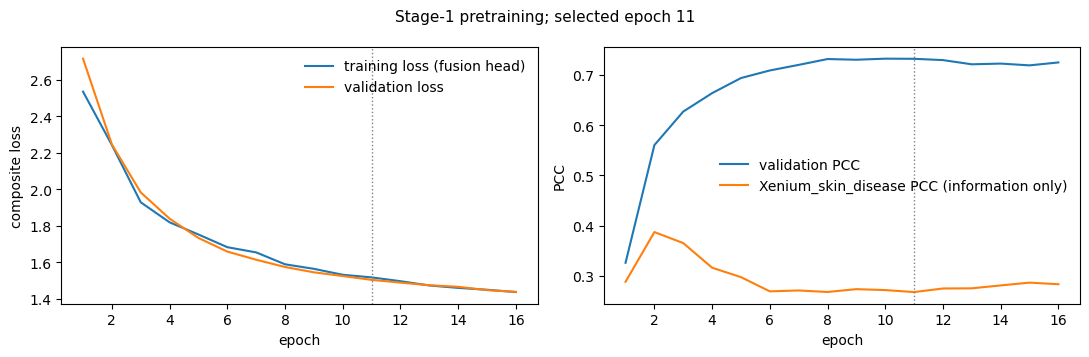

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(history["epoch"], history["train_loss"], label="training loss (fusion head)")
axes[0].plot(history["epoch"], history["val_loss"], label="validation loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("composite loss"); axes[0].legend(frameon=False)
axes[1].plot(history["epoch"], history["val_pcc"], label="validation PCC")
axes[1].plot(history["epoch"], history["monitor_pcc"], label=f"{TARGET_SAMPLE} PCC (information only)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("PCC"); axes[1].legend(frameon=False)
best = history.loc[history["val_score"].idxmax(), "epoch"]
for ax in axes: ax.axvline(best, color="grey", linestyle=":", linewidth=1)
fig.suptitle(f"Stage-1 pretraining; selected epoch {best:.0f}", fontsize=11)
plt.tight_layout(); plt.show()

## Step 4 — Pseudo-labels for the target with Cell2location

`pseudo_labels.py`: reference signatures from the atlas restricted to the target panel genes (`filter_genes`, negative-binomial regression), then Cell2location on all target spots in full batches; the 5 % quantile of the posterior cell abundance is exported (`output/cell2location/pseudo_labels/deconv.csv`) and converted to proportions where it is used. Step 6 reuses the signatures and settings.

| name | value | meaning |
|---|---|---|
| `reference_epochs`, `mapping_epochs` | 400, 30,000 | epochs of the regression and of the spatial model |
| `n_cells_per_location`, `detection_alpha` | 5, 20 | prior expected cells per spot; detection-efficiency prior strength |
| `posterior_samples` | 1,000 | posterior samples summarised into the exported abundance |
| `cell_count_cutoff`, `cell_percentage_cutoff2`, `nonz_mean_cutoff` | 5, 0.03, 1.12 | `filter_genes` cutoffs applied to the reference |

Reference: 54,063 cells x 375 genes, 13 classes in obs['cell_type']


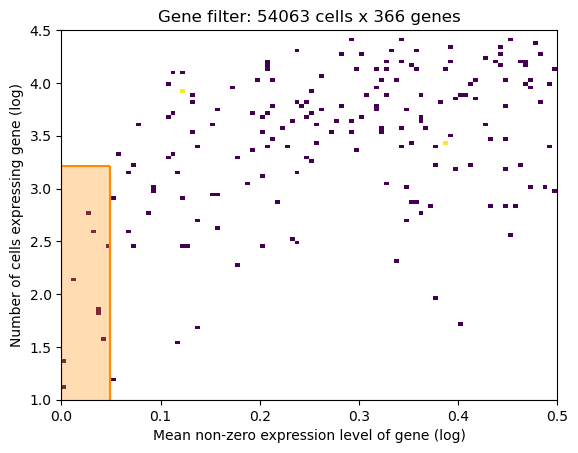

366 genes kept by filter_genes


Sampling local variables, batch:   0%|          | 0/22 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

4,723 spots x 366 shared genes, 13 cell types


Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

Saved output/cell2location/pseudo_labels/deconv.csv


,FB,KC,LE,MELA,Mast,Melanoma,Mye,Peri,SGEC,SMC,Schwann,T/NK,VE
spot_0,0.000052,0.890131,0.000003,0.000001,0.000029,9.857117e-07,0.000079,0.000012,0.000384,0.000147,0.000025,0.000090,0.000009
spot_1,0.000300,1.456508,0.000005,0.001751,0.003862,1.981690e-05,0.019955,0.064077,0.574578,0.001067,0.000026,0.224023,0.000041
spot_2,0.131709,0.115118,0.010008,0.000024,0.000189,1.064949e-05,0.037373,0.000049,0.095281,0.000037,0.000050,0.254526,0.000225
spot_3,0.509387,0.023765,0.000020,0.000002,0.000474,1.710191e-06,0.008152,0.000037,0.000666,0.000033,0.000039,0.003415,0.000216
spot_4,0.468010,0.013573,0.000036,0.000006,0.001432,1.104255e-06,0.009823,0.000198,0.000283,0.006568,0.000030,0.000527,0.000136


In [15]:
import pseudo_labels as pl

C2L_HP = dict(
    reference_epochs=400, mapping_epochs=30000,
    n_cells_per_location=5, detection_alpha=20, posterior_samples=1000,
    cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12,
)

reference = pl.build_reference(ATLAS, list(pseudo[TARGET_SAMPLE].var_names), labels_key="cell_type")
signatures = pl.estimate_signatures(reference, OUTPUT / "cell2location" / "reference", "cell_type", C2L_HP)
adata_target = pl.prepare_st(pseudo[TARGET_SAMPLE])
pseudo_labels = pl.run_cell2location(adata_target, signatures, OUTPUT / "cell2location" / "pseudo_labels", C2L_HP)
pseudo_labels.head()

## Step 5 — Stage 2: co-teaching adaptation

`adaptation.adapt`: two peers *f* and *g* start from the Stage-1 checkpoint; the trainable weights of *g* are perturbed with Gaussian noise (`perturbation_scale` × each tensor's standard deviation, seed `seed_g`). Gene encoder, morphology encoder and morphology head are frozen; the fusion head and the gene head are trained. In every minibatch each peer scores each spot by `MSE(fusion prediction, pseudo-label) + gamma · MSE(morphology-head prediction, pseudo-label)`, keeps the fraction `rho_e = 1 − tau · min((e + 1) / warmup_epochs, 1)` with the smallest scores, and its partner is updated on that selection with the Stage-1 loss. After the last epoch the peer with the lower fusion-head loss against the pseudo-labels over all target spots provides the transferred composition (`output/adaptation/crist_proportions.csv`). Ground-truth metrics are printed for information only.

| name | value | meaning |
|---|---|---|
| `lr`, `weight_decay`, `batch_size`, `grad_clip` | 1e-4, 1e-4, 1,024, 1.0 | Adam settings, as in Stage 1 |
| `w_pcc`, `w_rmse`, `w_jsd` | 1, 1, 1 | loss weights, as in Stage 1 |
| `gamma` | 10 | weight of the morphology-disagreement term |
| `tau`, `warmup_epochs`, `epochs` | 0.5, 5, 10 | maximal rejected fraction, its warm-up length, adaptation epochs |
| `perturbation_scale`, `seed_g` | 0.1, 123 | size and seed of the peer perturbation |

In [16]:
import adaptation as adp

ADAPT_HP = dict(
    lr=1e-4, weight_decay=1e-4, batch_size=1024, grad_clip=1.0,
    w_pcc=1.0, w_rmse=1.0, w_jsd=1.0,
    gamma=10.0, tau=0.5, warmup_epochs=5, epochs=10,
    perturbation_scale=0.1, seed_g=123,
)

crist_proportions, adapt_history, selected_peer = adp.adapt(checkpoint, target, pseudo_labels, ADAPT_HP, OUTPUT / "adaptation")
adapt_history

peer f:
  frozen 1,051,917 parameters (gene encoder, morphology encoder, morphology head); trainable 143,258 (fusion head, gene head)
peer g:
  frozen 1,051,917 parameters (gene encoder, morphology encoder, morphology head); trainable 143,258 (fusion head, gene head)


Before adaptation | vs ground truth: PCC=0.2677 RMSE=0.8315 JSD=0.3924



Epoch 1:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 1:  20%|██        | 1/5 [00:00<00:02,  1.48it/s]


Epoch 1:  60%|██████    | 3/5 [00:00<00:00,  4.67it/s]

...


Epoch 10:  20%|██        | 1/5 [00:00<00:02,  1.45it/s]


Epoch 10:  60%|██████    | 3/5 [00:00<00:00,  4.59it/s]

Epoch  10 | keep=0.50 | loss f=1.0670 g=1.0501 | f vs ground truth: PCC=0.8070 RMSE=0.4161 JSD=0.1623 | g vs ground truth: PCC=0.8110 RMSE=0.4083 JSD=0.1592


Fusion-head loss against the pseudo-labels after the last epoch: f=0.9560, g=0.9543 -> peer g provides the transferred composition


,epoch,keep_rate,loss_f,loss_g,pcc_f,rmse_f,jsd_f,pcc_g,rmse_g,jsd_g
0,1,0.9,1.547297,1.546154,0.432746,0.661867,0.299262,0.524922,0.620490,0.275369
1,2,0.8,1.447080,1.446736,0.538228,0.616400,0.269867,0.630573,0.581485,0.247205
2,3,0.7,1.353035,1.355675,0.618967,0.584610,0.248580,0.686827,0.552848,0.229621
3,4,0.6,1.276552,1.290302,0.680651,0.552712,0.229264,0.726459,0.523066,0.213508
4,5,0.5,1.201109,1.209899,0.721395,0.522168,0.212687,0.754584,0.493510,0.198345
5,6,0.5,1.176401,1.177162,0.751511,0.492367,0.197683,0.776891,0.465068,0.184499
6,7,0.5,1.141079,1.135313,0.773862,0.465651,0.184977,0.791655,0.442577,0.174373
7,8,0.5,1.103792,1.114614,0.787847,0.446702,0.176324,0.800301,0.427865,0.167235
8,9,0.5,1.080697,1.076696,0.798858,0.429981,0.168603,0.806881,0.416148,0.162165
9,10,0.5,1.066951,1.050116,0.806979,0.416124,0.162334,0.811011,0.408275,0.159240


### Effect of the adaptation

The Stage-1 model applied to the target without adaptation versus the adapted model, both against the target's ground truth: mean per-spot PCC, RMSE and JSD, a paired one-sided Wilcoxon test over spots, the composition maps (ground truth, adapted, not adapted) and the spots on which the adaptation improves each metric (green).

In [17]:
import evaluation as ev
import plotting

pretrained_proportions = pt.predict_target(model, target)                       # Stage-1 model, no adaptation
per_adapt, summary_adapt, valid = ev.compare(target["raw_counts"], {"Adapted (Stage 2)": crist_proportions,
                                                                     "Pretrained (no adaptation)": pretrained_proportions},
                                             target["spot_ids"], cell_types)
summary_adapt

3,688 spots with annotated cells; mean per-spot metrics:


,PCC ↑,RMSE ↓,JSD ↓
Adapted (Stage 2),0.811011,0.102579,0.159240
Pretrained (no adaptation),0.267738,0.221970,0.392392


In [18]:
ev.significance(per_adapt, "Adapted (Stage 2)", "Pretrained (no adaptation)")

,Pretrained (no adaptation) mean,Adapted (Stage 2) mean,Adapted (Stage 2) better (fraction of spots),paired Wilcoxon p (one-sided)
metric,,,,
PCC ↑,0.267738,0.811011,0.952007,0.0
RMSE ↓,0.221970,0.102579,0.971529,0.0
JSD ↓,0.392392,0.159240,0.953091,0.0


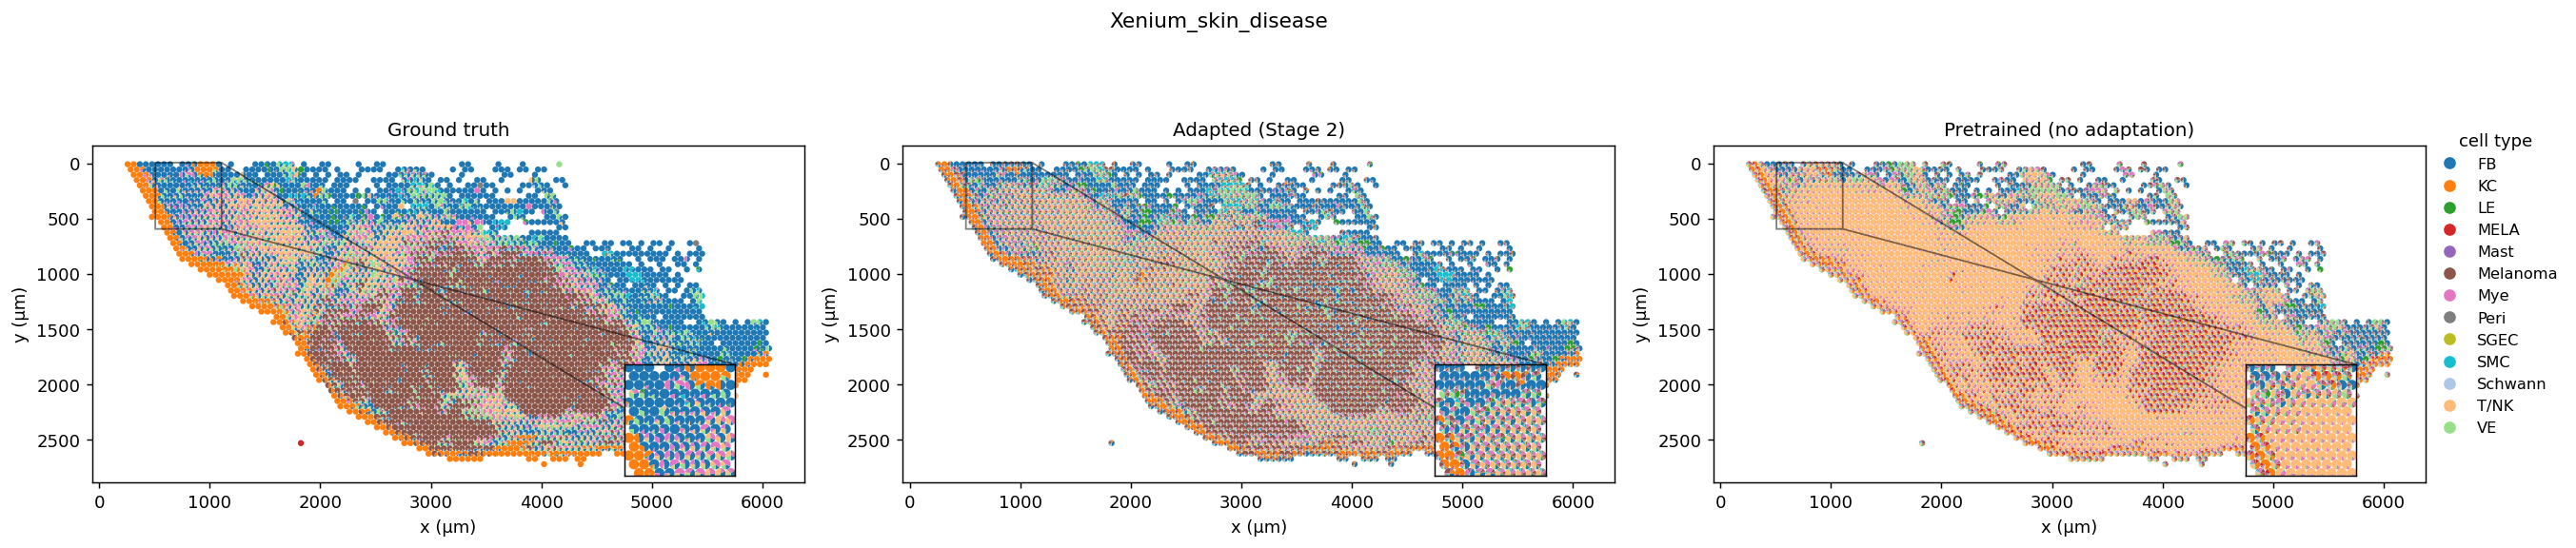

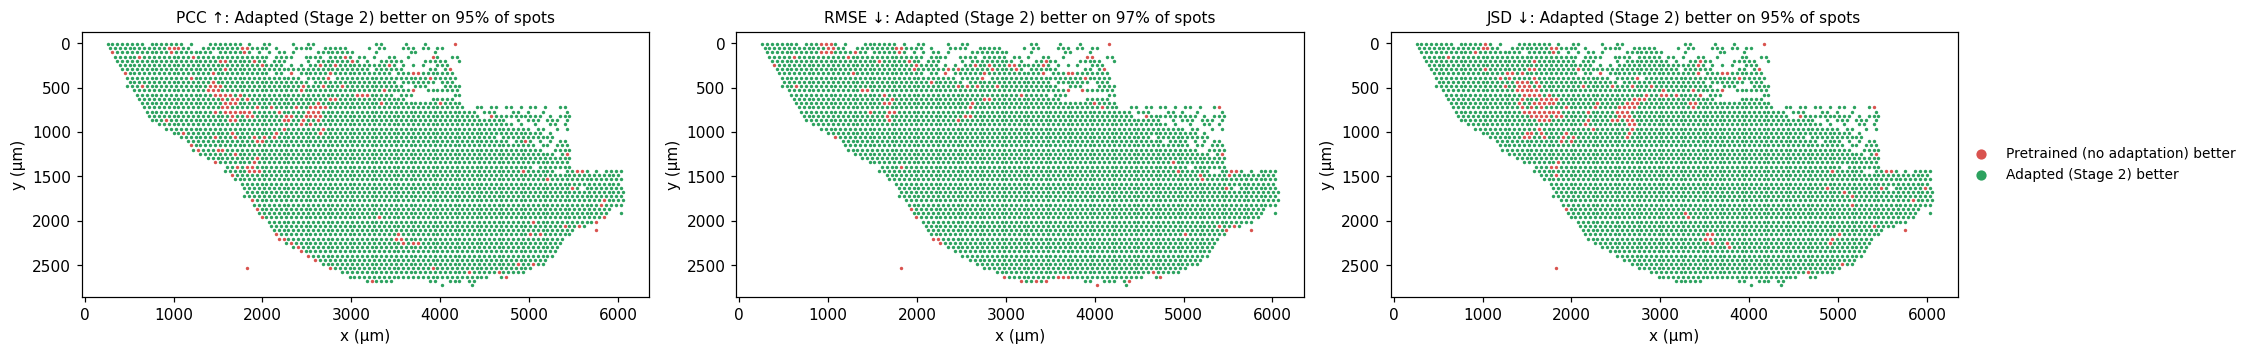

In [19]:
xy_target = pseudo[TARGET_SAMPLE].obsm["spatial"][valid]
gt_proportions = target["raw_counts"][valid] / target["raw_counts"][valid].sum(axis=1, keepdims=True)
fig = plotting.composition_maps(xy_target, {"Ground truth": gt_proportions,
                                            "Adapted (Stage 2)": ev.to_proportions(crist_proportions, target["spot_ids"], cell_types)[valid],
                                            "Pretrained (no adaptation)": ev.to_proportions(pretrained_proportions, target["spot_ids"], cell_types)[valid]},
                                cell_types, palette, radius=ps.SPOT_DIAMETER_UM / 2, title=TARGET_SAMPLE)
plt.show()
fig = plotting.improvement_maps(xy_target, per_adapt, "Adapted (Stage 2)", "Pretrained (no adaptation)", ev.TITLES)
plt.show()

## Step 6 — Inject the transferred composition into Cell2location

`prior_injection.inject_prior` (with `cell2location_presence_module.py`) runs Cell2location with the signatures and settings of step 4, but the prior mean of the cell abundance of type *k* at spot *u* becomes `mu_uk + lambda · eta_u · p_uk`: Cell2location's own prior mean, its latent number of cells at the spot and the CRIST proportion of step 5. Result: `output/cell2location/crist_injected/deconv.csv`.

| name | value | meaning |
|---|---|---|
| `injection_strength` | 10 | λ; 0 recovers step 4 |

In [20]:
import prior_injection as pi

INJECTION_HP = dict(C2L_HP, injection_strength=10.0)

crist_injected = pi.inject_prior(adata_target, signatures, crist_proportions, OUTPUT / "cell2location" / "crist_injected", INJECTION_HP)
crist_injected.head()

Prior aligned for 13/13 cell types, values in [0.000, 0.954]
4,723 spots x 366 shared genes, 13 cell types


Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

Saved output/cell2location/crist_injected/deconv.csv


,FB,KC,LE,MELA,Mast,Melanoma,Mye,Peri,SGEC,SMC,Schwann,T/NK,VE
spot_0,0.015597,2.808323,0.000053,0.000275,0.000551,0.013350,0.000630,0.000180,0.000073,0.017903,0.000374,0.000221,0.000641
spot_1,0.011775,8.601459,0.000292,0.029212,0.006290,0.061594,0.105864,0.147531,0.858733,0.208742,0.007155,0.302034,0.000585
spot_2,0.750445,0.442170,0.056709,0.000210,0.000286,0.034210,0.136098,0.000313,0.066874,0.001785,0.000093,0.287288,0.007934
spot_3,4.862919,0.120605,0.000041,0.000005,0.001049,0.002293,0.045175,0.000338,0.001425,0.000978,0.000079,0.004989,0.000104
spot_4,4.370433,0.061216,0.000052,0.000007,0.004080,0.002876,0.064349,0.000941,0.001265,0.040697,0.000036,0.003331,0.000239


## Step 7 — Comparison with the ground truth

`evaluation.compare` converts both results to per-spot proportions and computes, on the spots with ≥ 1 labelled cell, the per-spot PCC, RMSE (over cell types) and JSD against the composition of the labelled cells; the table gives their means. `evaluation.significance` tests with a paired one-sided Wilcoxon test over spots that CRIST beats Cell2location on each metric. `evaluation.boxplots` draws the per-spot distributions in the style of the paper's benchmark figure; `plotting.composition_maps` draws every spot as a pie (ground truth, CRIST, Cell2location) and `plotting.improvement_maps` marks in green the spots on which CRIST improves each metric.

* **Cell2location** — the reference-based model alone (step 4);
* **CRIST** — the same model with the transferred composition injected as prior (step 6), the configuration reported as CRIST in the paper.

In [21]:
per_spot, summary, valid = ev.compare(target["raw_counts"], {"CRIST": crist_injected, "Cell2location": pseudo_labels},
                                      target["spot_ids"], cell_types)
summary

3,688 spots with annotated cells; mean per-spot metrics:


,PCC ↑,RMSE ↓,JSD ↓
CRIST,0.877955,0.069650,0.092920
Cell2location,0.728129,0.117507,0.164063


In [22]:
ev.significance(per_spot, "CRIST", "Cell2location")

,Cell2location mean,CRIST mean,CRIST better (fraction of spots),paired Wilcoxon p (one-sided)
metric,,,,
PCC ↑,0.728129,0.877955,0.929230,0.0
RMSE ↓,0.117507,0.069650,0.924892,0.0
JSD ↓,0.164063,0.092920,0.931941,0.0


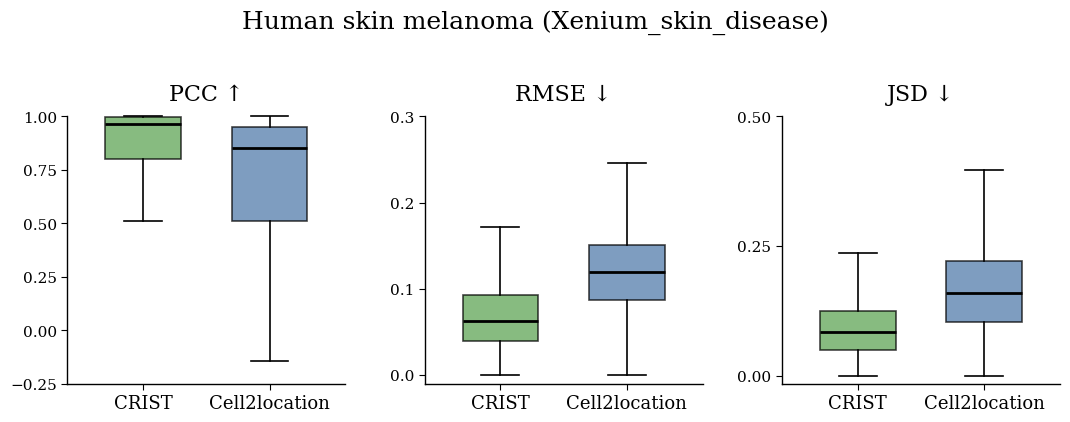

In [23]:
fig = ev.boxplots(per_spot, "Human skin melanoma (Xenium_skin_disease)", methods=["CRIST", "Cell2location"])
fig.savefig(OUTPUT / "crist_vs_cell2location_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

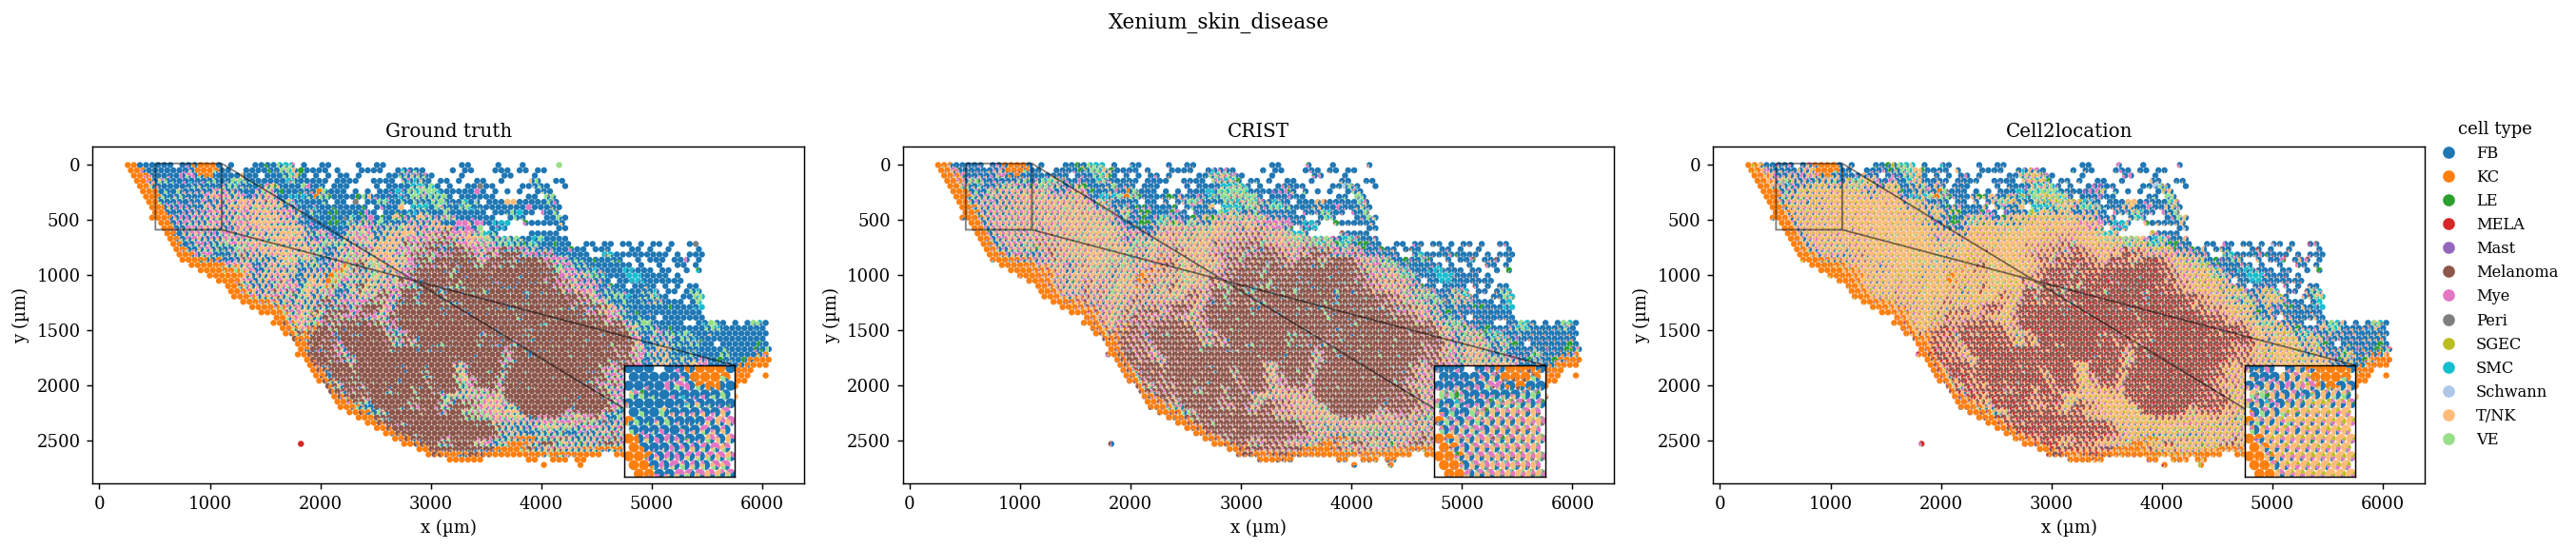

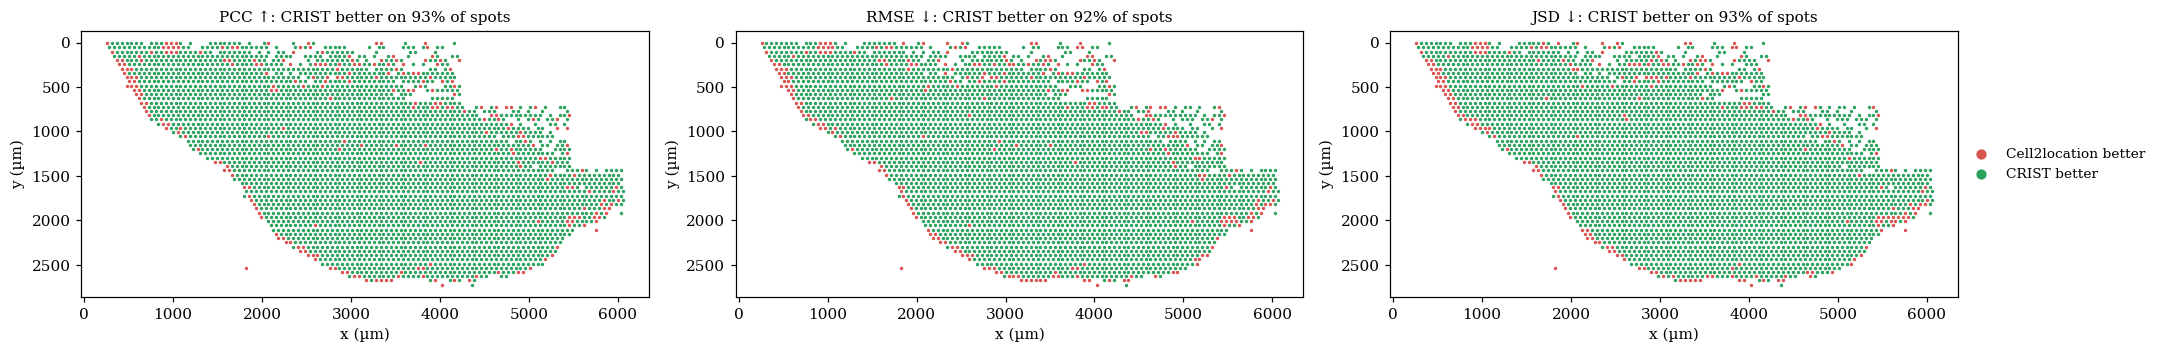

In [24]:
fig = plotting.composition_maps(xy_target, {"Ground truth": gt_proportions,
                                            "CRIST": ev.to_proportions(crist_injected, target["spot_ids"], cell_types)[valid],
                                            "Cell2location": ev.to_proportions(pseudo_labels, target["spot_ids"], cell_types)[valid]},
                                cell_types, palette, radius=ps.SPOT_DIAMETER_UM / 2, title=TARGET_SAMPLE)
plt.show()
fig = plotting.improvement_maps(xy_target, per_spot, "CRIST", "Cell2location", ev.TITLES)
plt.show()